In [1]:
#source /export/ciaox/bin/ciao.bash -o
PFILES="./param;$ASCDS_INSTALL/param:$ASCDS_INSTALL/contrib/param"
mkdir -p ./param
ASCDS_WORK_PATH=./


## Download

In [2]:
/bin/rm -rf 1838 
download_chandra_obsid 1838


  Type     Format      Size  0........H.........1  Download Time Average Rate
  ---------------------------------------------------------------------------
  readme   ascii      11 Kb  ####################          < 1 s  247.3 kb/s
  oif      fits       23 Kb  ####################          < 1 s  2683.2 kb/s
  vv       pdf        33 Kb  ####################          < 1 s  3378.3 kb/s
  cntr_img fits       75 Kb  ####################          < 1 s  5935.4 kb/s
  cntr_img jpg       446 Kb  ####################          < 1 s  8408.6 kb/s
  evt2     fits        3 Mb  ####################          < 1 s  18984.4 kb/s
  full_img fits       48 Kb  ####################          < 1 s  4756.3 kb/s
  full_img jpg        47 Kb  ####################          < 1 s  4964.0 kb/s
  bpix     fits       12 Kb  ####################          < 1 s  558.6 kb/s
  fov      fits        6 Kb  ####################          < 1 s  829.0 kb/s
  eph1     fits      281 Kb  ####################          < 1 s 

In [3]:
chandra_repro 1838 out="./" clob+


Processing input directory '/stage/pool1/kjg/thread/1838'

Resetting afterglow status bits in evt1.fits file...

Running acis_build_badpix and acis_find_afterglow to create a new bad pixel file...

Running acis_process_events to reprocess the evt1.fits file...
Filtering the evt1.fits file by grade and status and time...
Applying the good time intervals from the flt1.fits file...
The new evt2.fits file is: /stage/pool1/kjg/thread/acisf01838_repro_evt2.fits

Updating the event file header with chandra_repro HISTORY record
Creating FOV file...
Setting observation-specific bad pixel file in local ardlib.par.

Cleaning up intermediate files

         /stage/pool1/kjg/thread/acisf01838_repro_bpix1.fits
         Run 'punlearn ardlib' when analysis of this dataset completed.

The data have been reprocessed.
Start your analysis with the new products in
/stage/pool1/kjg/thread



In [4]:
/bin/rm -f acis_1838_*
dmcopy acisf01838_repro_evt2.fits"[ccd_id=7]" acis_1838_c7.evt clob+
fluximage acis_1838_c7.evt acis_1838 bin=2 band="0.3:8:2.3" clob+

Running fluximage
Version: 28 November 2018

Using energy range 0.3 to 8.0 keV and exposure-map energy of 2.3 keV.
Aspect solution pcadf084244404N003_asol1.fits found.
Bad-pixel file acisf01838_repro_bpix1.fits found.
Mask file acisf01838_000N003_msk1.fits found.

The output images will have 555 by 555 pixels, pixel size of 0.984 arcsec,
    and cover x=3638.5:4748.5:2,y=3844.5:4954.5:2.

Running tasks in parallel with 4 processors.
Creating aspect histogram for obsid 1838
Creating instrument map for obsid 1838
Creating exposure map for obsid 1838
Thresholding data for obsid 1838
Exposure-correcting image for obsid 1838

The following files were created:

 The clipped counts image is:
     acis_1838_0.3-8_thresh.img

 The clipped exposure map is:
     acis_1838_0.3-8_thresh.expmap

 The exposure-corrected image is:
     acis_1838_0.3-8_flux.img



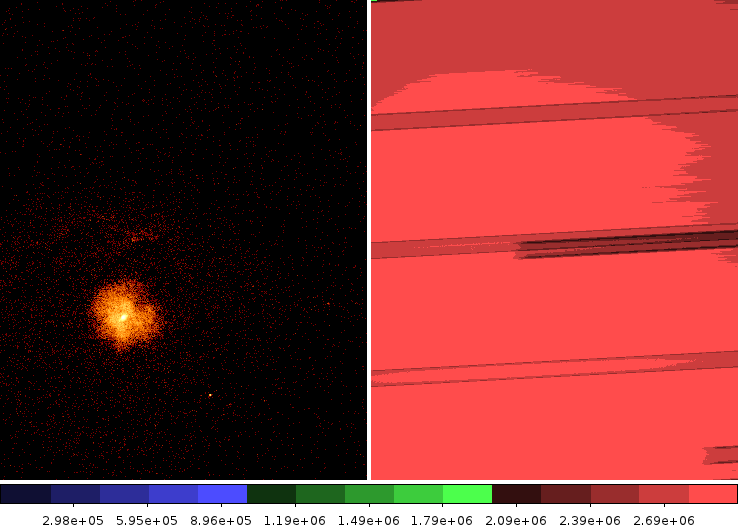

In [5]:
ds9 acis_1838_0.3-8_thresh.img -scale log -cmap bb\
    acis_1838_0.3-8_thresh.expmap -scale linear -cmap staircase\
    -saveimage png ds9_01.png -quit

display < ds9_01.png

In [6]:
cat << EOM > annuli.reg
# Region file format: CIAO version 1.0
annulus(4072,4246,10,15)
annulus(4072,4246,15,20)
annulus(4072,4246,20,25)
annulus(4072,4246,25,30)
annulus(4072,4246,30,35)
annulus(4072,4246,35,40)
annulus(4072,4246,40,45)
annulus(4072,4246,45,50)
annulus(4072,4246,50,55)
annulus(4072,4246,55,60)
annulus(4072,4246,60,65)
annulus(4072,4246,65,70)
annulus(4072,4246,70,75)
annulus(4072,4246,75,80)
annulus(4072,4246,80,85)
annulus(4072,4246,85,90)
annulus(4072,4246,90,95)
annulus(4072,4246,95,100)
annulus(4072,4246,100,105)
annulus(4072,4246,105,110)
annulus(4072,4246,110,115)
annulus(4072,4246,115,120)
annulus(4072,4246,120,125)
annulus(4072,4246,125,130)
annulus(4072,4246,130,135)
annulus(4072,4246,135,140)
annulus(4072,4246,140,145)
annulus(4072,4246,145,150)
annulus(4072,4246,150,155)
annulus(4072,4246,155,160)
annulus(4072,4246,160,165)
annulus(4072,4246,165,170)
annulus(4072,4246,170,175)
annulus(4072,4246,175,180)
annulus(4072,4246,180,185)
annulus(4072,4246,185,190)
annulus(4072,4246,190,195)
annulus(4072,4246,195,200)
EOM


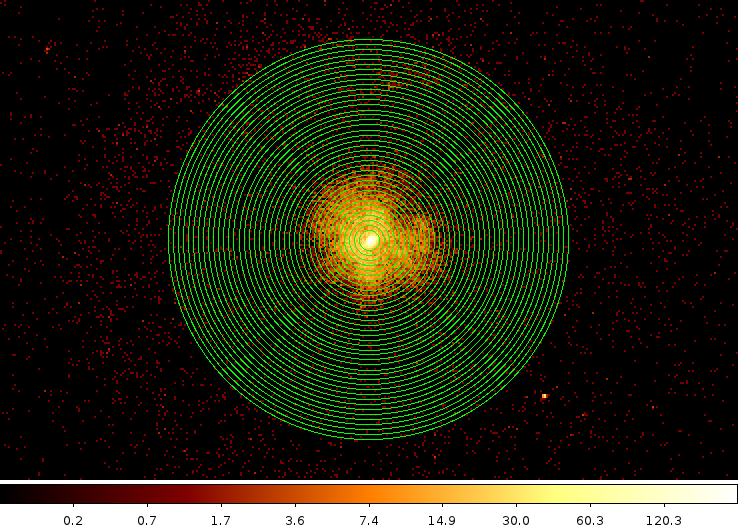

In [7]:
ds9 acis_1838_0.3-8_thresh.img -scale log -cmap bb\
  -region annuli.reg \
  -pan to 4072 4246 physical -zoom 2 \
  -saveimage png ds9_02.png -quit

display < ds9_02.png

In [8]:
cat << EOM > annuli_bgd.reg
# Region file format: CIAO version 1.0
annulus(4070,4250,200,225)
EOM


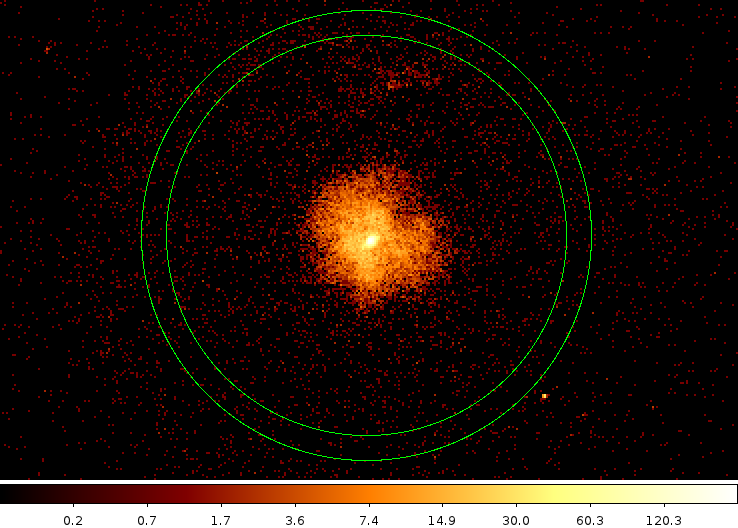

In [9]:
ds9 acis_1838_0.3-8_thresh.img -scale log -cmap bb\
  -region annuli_bgd.reg \
  -pan to 4072 4246 physical -zoom 2 \
  -saveimage png ds9_03.png -quit

display < ds9_03.png

## Remove contam


In [10]:
cat << EOM > contam.reg
# Region file format: CIAO version 1.0
circle(4246.5,4090.5,8)
EOM


In [11]:
dmcopy "acis_1838_c7.evt[exclude sky=region(contam.reg)]" \
  acis_1838_excl_evt2.fits clob+

## Run dmextract

In [12]:
pset dmextract infile="acis_1838_c7.evt[energy=300:8000][bin sky=@annuli.reg]"
pset dmextract outfile=1838_rprofile.fits
pset dmextract bkg="acis_1838_c7.evt[energy=300:8000][bin sky=@annuli_bgd.reg]"
pset dmextract opt=generic
pset dmextract exp=acis_1838_0.3-8_thresh.expmap
pset dmextract bkgexp=acis_1838_0.3-8_thresh.expmap
dmextract mode=h clob+


In [13]:
dmlist 1838_rprofile.fits cols

 
--------------------------------------------------------------------------------
Columns for Table Block HISTOGRAM
--------------------------------------------------------------------------------
 
ColNo  Name                 Unit        Type             Range
   1   sky(X,Y)             pixel        Real8          -Inf:+Inf            Position
   2   EQPOS(RA,Dec)        deg          Real8          -360.0:      360.0   Position
   3   SHAPE                             String[16]                          Region shape type
   4   R[2]                 pixel        Real8(2)       -Inf:+Inf            Radius
   5   RMID                 pixel        Real8          -Inf:+Inf            Mean of valid R[2] values
   6   ROTANG[2]            pixel        Real8(2)       -Inf:+Inf            Angle
   7   COMPONENT                         Int2           -                    Component number
   8   COUNTS               count        Real8          -Inf:+Inf            Counts
   9   ERR_COUNTS     

In [14]:
###pset dmtcalc infile=1838_rprofile.fits
###pset dmtcalc outfile=1838_rprofile_rmid.fits
###pset dmtcalc expression="rmid=0.5*(R[0]+R[1])"
###dmtcalc mode=h clob+

In [15]:
dmlist 1838_rprofile.fits'[cols R,RMID]' data row=1:5

 
--------------------------------------------------------------------------------
Data for Table Block HISTOGRAM
--------------------------------------------------------------------------------
 
ROW    R[2]                                     RMID
 
     1                [       10.0        15.0]                12.50
     2                [       15.0        20.0]                17.50
     3                [       20.0        25.0]                22.50
     4                [       25.0        30.0]                27.50
     5                [       30.0        35.0]                32.50


## Try with an image

In [16]:
pset dmextract infile="acis_1838_0.3-8_thresh.img[bin sky=@annuli.reg]"
pset dmextract outfile=1838_rprofile_img.fits
pset dmextract bkg="acis_1838_0.3-8_thresh.img[bin sky=@annuli_bgd.reg]"
pset dmextract opt=generic
pset dmextract exp=acis_1838_0.3-8_thresh.expmap
pset dmextract bkgexp=acis_1838_0.3-8_thresh.expmap
dmextract mode=h clob+


In [17]:
#pset dmtcalc infile=1838_rprofile_img.fits
#pset dmtcalc outfile=1838_rprofile_img_rmid.fits
#pset dmtcalc expression="rmid=0.5*(R[0]+R[1])"
#dmtcalc mode=h clob+

## Plot it

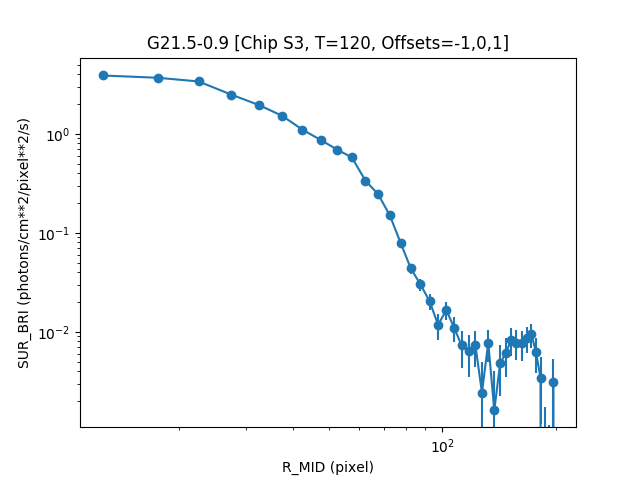

In [18]:
cat << EOM > c1.py
from pycrates import read_file
import matplotlib.pylab as plt

tab = read_file("1838_rprofile.fits")
xx = tab.get_column("rmid").values
yy = tab.get_column("sur_bri").values
ye = tab.get_column("sur_bri_err").values

plt.errorbar(xx,yy,yerr=ye, marker="o")
plt.xscale("log")
plt.yscale("log")
plt.xlabel("R_MID (pixel)")
plt.ylabel("SUR_BRI (photons/cm**2/pixel**2/s)")
plt.title('G21.5-0.9 [Chip S3, T=120, Offsets=-1,0,1]')
plt.savefig("chips_01.png")
EOM

python c1.py
display < chips_01.png


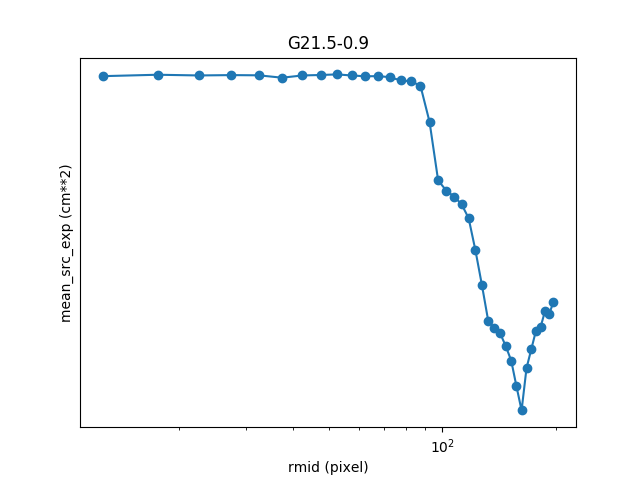

In [19]:
cat << EOM > c2.py
from pycrates import read_file
import matplotlib.pylab as plt

tab = read_file("1838_rprofile.fits")
xx = tab.get_column("rmid").values
yy = tab.get_column("mean_src_exp").values
plt.plot(xx,yy, marker="o")
plt.xscale("log")
plt.yscale("log")
plt.xlabel("rmid (pixel)")
plt.ylabel("mean_src_exp (cm**2)")
plt.title("G21.5-0.9")

plt.savefig("chips_02.png")
EOM

python c2.py
display < chips_02.png


## Sherpa


Dataset               = 1
Method                = levmar
Statistic             = chi2
Initial fit statistic = 4.31336e+11
Final fit statistic   = 234.411 at function evaluation 30
Data points           = 38
Degrees of freedom    = 35
Probability [Q-value] = 2.33661e-31
Reduced statistic     = 6.69744
Change in statistic   = 4.31336e+11
   src.r0         124.618      +/- 0           
   src.beta       4.10468      +/- 0.0306006   
   src.ampl       1.51639e-06  +/- 1.70577e-08 


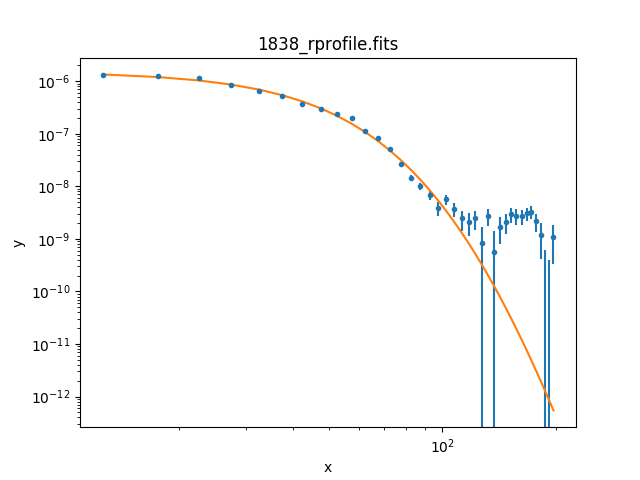

In [20]:
cat << EOM > s1.py

from sherpa.astro.ui import *
import matplotlib.pylab as plt
load_data(1,"1838_rprofile.fits", 3, ["RMID","SUR_FLUX","SUR_FLUX_ERR"])
set_source("beta1d.src")
src.r0 = 105
src.beta = 4
src.ampl = 0.00993448

freeze(src.xpos)

fit()
plot_fit()

plt.xscale("log")
plt.yscale("log")
#plt.xlim(10, 200)
#plt.ylim(0.0001, 10)

plt.savefig("sherpa_01.png")
EOM

python s1.py
display < sherpa_01.png


# Cleanup

In [21]:
/bin/rm -rf 1838
/bin/rm -f acisf* pcadf* 
